In [25]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [62]:
from utils.data_loader import DataLoader
from utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import keras
import tensorflow as tf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [27]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [ ]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")

def rmse(y_true, y_pred):
    """root mean squared error metric for regression evaluation"""
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

def r2(y_true, y_pred):
    """R-squared metric for regression evaluation"""
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

def custom_callback( monitor, mode, patience, filepath):
    """ early stopping and model checkpoint callbacks for training """
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc

def plot_regression_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot MAE
    axes[0].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[0].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[0].set_title('Model MAE Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    def metric_at(name, epoch):
        return f"{history.history[name][epoch]:.4f}"

    best = int(np.argmin(history.history['val_loss']))

    print(
        f"\nBest Epoch: {best+1} | "
        f"Train MAE: {metric_at('mae', best)} | "
        f"Val MAE: {metric_at('val_mae', best)} | "
        f"Train Loss: {metric_at('loss', best)} | "
        f"Val Loss: {metric_at('val_loss', best)} |"
        f"Train MAPE: {metric_at('mape', best)} | "
        f"Val MAPE: {metric_at('val_mape', best)} |"
        f"Train RMSE: {metric_at('rmse', best)} | "
        f"Val RMSE: {metric_at('val_rmse', best)} |"
        f"Train R²: {metric_at('r2', best)} | "
        f"Val R²: {metric_at('val_r2', best)} |"
        )

### Data Acquisition

In [29]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [30]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [31]:
# Based on the above summary target variable "second_term_gpa" has 159 null values; should be dropped for regression task. 
print(f"Number of rows before dropping nulls in target variable: {clean_df.shape[0]}")

# replace ? with nan in second_term_gpa column
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in target variable: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
print(f"Number of rows after dropping nulls in target variable: {clean_df.shape[0]}")

Number of rows before dropping nulls in target variable: 1437
Number of rows with nulls in target variable: 160
Number of rows after dropping nulls in target variable: 1277


In [32]:
# Feature and target separation
y = clean_df["second_term_gpa"] # Target variable
X = clean_df.drop(columns=["second_term_gpa", "first_year_persistence", "school"]) # Drop school - unique value; first_year_persistence - data leakage concerns; second_term_gpa - target variable

### Data Exploration

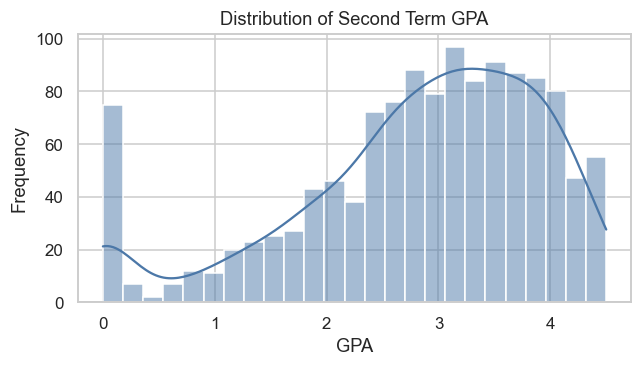

In [33]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [34]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 72


### Train-Test Protocol

In [35]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 12), X_val: (128, 12), X_test: (256, 12)


In [36]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7
353,2.25,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7
1354,3.4,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9


### Data Cleaning

In [37]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="random_forest")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

C:\Vivek\Soft\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [38]:
# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_term_gpa_missing,high_school_average_mark_missing,...,funding_4,funding_5,funding_8,funding_9,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3
78,0.485630,1,0,0,3,0.909471,0.455197,7,0,1,...,True,False,False,False,True,False,False,True,False,False
353,-0.762264,0,0,1,2,0.306190,0.045668,7,0,0,...,False,False,False,False,False,True,False,False,True,False
1354,0.366174,1,0,0,4,1.024018,1.329298,8,0,1,...,True,False,False,False,True,False,False,False,True,False
510,1.165193,0,1,1,4,-0.648370,1.576470,9,0,0,...,False,False,False,False,False,True,False,False,True,False
338,-0.470226,0,1,1,2,-0.171090,-0.708310,9,0,0,...,False,False,False,False,False,True,False,True,False,False


### Model Construction

In [ ]:
# Construct the regression model
model = keras.Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)  # regression output (linear)
])

model.summary()

C:\Vivek\Soft\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,489 (60.50 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Model compilation
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae", "mape", rmse, r2]
)

In [65]:
# Calling custom callbacks
early_stopping, model_checkpoint = custom_callback(monitor="val_loss", mode="min", patience=20, filepath=project_path/"second_term_gpa_regression/models/regression_model.keras")

# Model training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4857 - mae: 0.5210 - mape: 63331836.4286 - mse: 0.4857 - r2: 0.6291 - rmse: 0.6823
Epoch 1: val_loss improved from None to 0.59026, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.5122 - mae: 0.5455 - mape: 61775376.0000 - mse: 0.5122 - r2: 0.5952 - rmse: 0.7026 - val_loss: 0.5903 - val_mae: 0.5429 - val_mape: 59995760.0000 - val_mse: 0.5903 - val_r2: 0.5009 - val_rmse: 0.7448
Epoch 2/200
24/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4795 - mae: 0.5360 - mape: 52623660.2978 - mse: 0.4795 - r2: 0.6103 - rmse: 0.6859
Epoch 2: val_loss did not improve from 0.59026
28/28 ━━━━━━━━━━━━━━━━━

### Training History

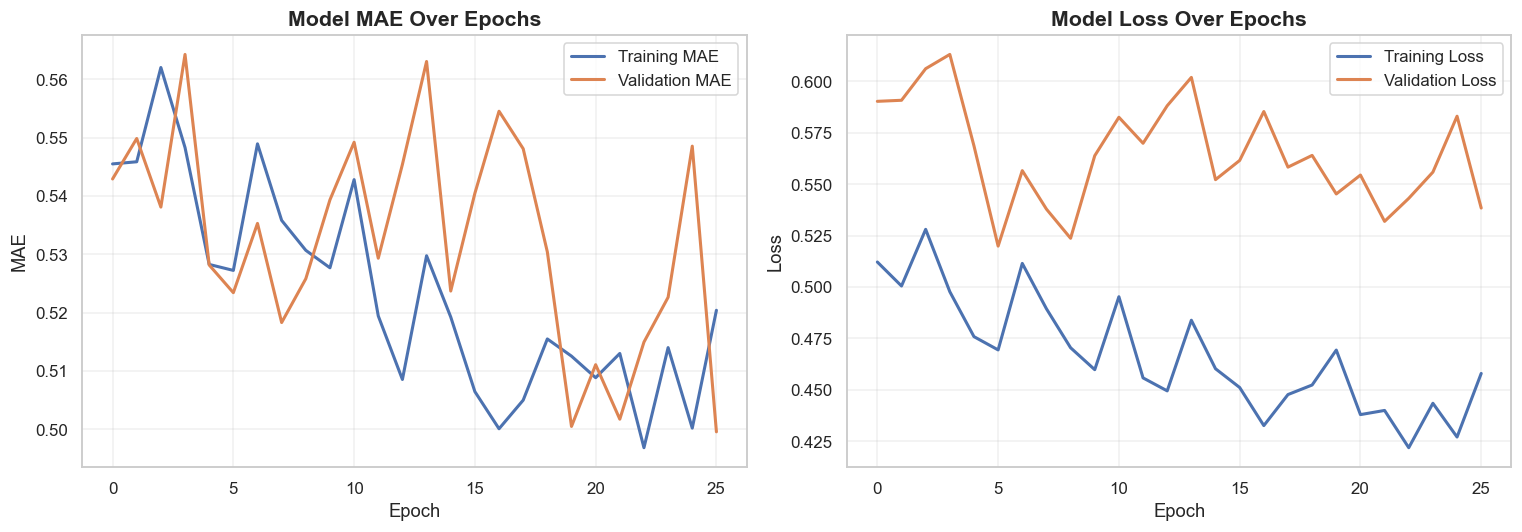


Best Epoch: 6 | Train MAE: 0.5272 | Val MAE: 0.5234 | Train Loss: 0.4694 | Val Loss: 0.5199 |Train MSE: 0.4694 | Val MSE: 0.5199 |Train MAPE: 57654772.0000 | Val MAPE: 57462996.0000 |Train RMSE: 0.6755 | Val RMSE: 0.6997 |Train R²: 0.5877 | Val R²: 0.5588 |


In [67]:
# Plot training history
plot_regression_history(history)

In [73]:
# Evaluate on test set
test_loss, test_mae, test_mse, test_mape, test_rmse, test_r2 = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE: {test_mae:.4f} | Test MSE: {test_mse:.4f} | Test MAPE: {test_mape:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")


Test MAE: 0.4781 | Test MSE: 0.3843 | Test MAPE: 49736400.0000 | Test RMSE: 0.6106 | Test R²: 0.6258


### Predictions

In [ ]:
# Predictions vs actuals on test set
test_df = pd.DataFrame({
    "Actual GPA": y_test,
    "Predicted GPA": model.predict(X_test).ravel(),
    "MAE": np.abs(y_test - model.predict(X_test).ravel()),
    "MSE": (y_test - model.predict(X_test).ravel())**2
})
display(test_df)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Actual GPA,Predicted GPA,MAE,MSE
460,3.886364,3.410328,0.476036,0.226610
810,2.222222,2.875345,0.653123,0.426570
1024,3.100000,2.966798,0.133202,0.017743
52,2.235294,2.666080,0.430786,0.185576
44,2.975000,3.678701,0.703701,0.495195
...,...,...,...,...
1279,3.604167,3.815166,0.210999,0.044520
1275,0.250000,1.622721,1.372721,1.884364
599,3.500000,3.405298,0.094702,0.008968
698,3.440000,3.077984,0.362016,0.131056


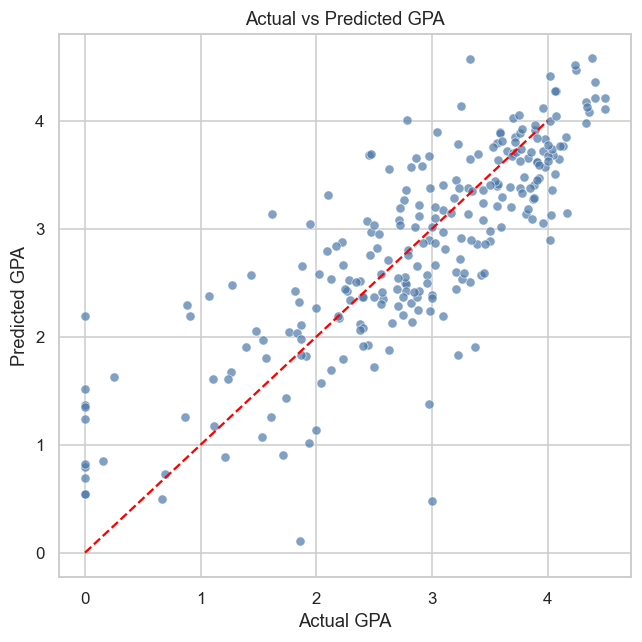

In [74]:
# Scatter plot of actual vs predicted GPA
plt.figure(figsize=(6,6))
sns.scatterplot(x="Actual GPA", y="Predicted GPA", data=test_df, color="#4c78a8", alpha=0.7)
plt.plot([0, 4], [0, 4], color="red", linestyle="--")  # Line for perfect predictions
plt.title("Actual vs Predicted GPA")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.tight_layout()
plt.show()